In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

grid_features = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_final_feature_set.csv")
grid_full = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_data_final_preprocessed_15min.csv")

grid_features = grid_features.reset_index(drop=True)
grid_full = grid_full.reset_index(drop=True)

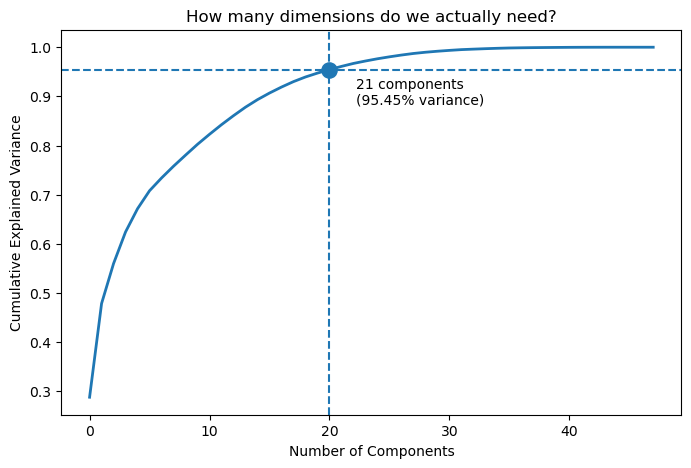

Optimal number of components: 21


In [42]:
# PCA for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(grid_features)

pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

threshold = 0.95
n_components = np.argmax(cum_var >= threshold) + 1

plt.figure(figsize=(8,5))
plt.plot(cum_var, linewidth=2)

plt.scatter(n_components-1, cum_var[n_components-1], s=120)
plt.axvline(n_components-1, linestyle='--')
plt.axhline(cum_var[n_components-1], linestyle='--')

plt.text(
    n_components + 1.2, 
    cum_var[n_components-1] - 0.015,
    f"{n_components} components\n({cum_var[n_components-1]*100:.2f}% variance)",
    fontsize=10,
    verticalalignment='top'
)

plt.title("How many dimensions do we actually need?")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()
print("Optimal number of components:", n_components)

In [43]:
#Using VIF for feature selection
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X = grid_features.copy()
X = X.dropna()  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = list(grid_features.columns)
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(len(list(grid_features.columns)))]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

c:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                        Feature         VIF
0                        temp_c         inf
6                 demand_avg_mw         inf
5                   wind_gen_mw         inf
4                  solar_gen_mw         inf
37                    wind_ramp         inf
38               renewable_ramp         inf
30         heating_degree_hours         inf
29         cooling_degree_hours         inf
36                   solar_ramp         inf
47                  net_load_mw         inf
15            solar_penetration  600.841165
16  total_renewable_penetration  514.276133
11                demand_lag_1h  286.703258
13              temp_rolling_3h  223.771450
20              net_load_lag_1h  118.414230
35                net_load_ramp   65.608978
21                 temp_lag_24h   56.482290
12             net_load_lag_24h   54.119254
18               demand_lag_24h   48.886396
26          temp_rolling_max_3d   42.346196
25         temp_rolling_mean_7d   38.026500
10                  demand_ramp 

In [44]:
if_features_final = [
    'net_load_ramp',
    'demand_ramp',
    'solar_ramp',
    'wind_ramp',
    'demand_volatility_6h',
    'solar_penetration',
    'heat_index_c',
    'heatwave_index',
    'humidity_pct',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'demand_rolling_std_7d',
    'demand_rolling_max_24h',
    'is_weekend',
    'is_peak_hour',
    'low_ren_high_dem',
    'is_extreme_temp',
    'is_extreme_demand',
    'dhi_wm2',
]

X = grid_features[if_features_final].copy()
print(f"\nFinal dataset shape: {X.shape}")


Final dataset shape: (105216, 21)


In [45]:
# Isolation Forest
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if_model = IsolationForest(
    contamination=0.05,  
    n_estimators=100,
    random_state=42,
    n_jobs=-1  
)

if_model.fit(X_scaled)
predictions = if_model.predict(X_scaled)
scores = if_model.decision_function(X_scaled)

anomalies_df = X.loc[X.index].copy()  
anomalies_df['if_anomaly_flag'] = (predictions == -1).astype(int)  
anomalies_df['if_anomaly_score'] = scores

full_df = anomalies_df.copy()
anomalies_df = anomalies_df[anomalies_df['if_anomaly_flag'] == 1].copy()

print(f"Total rows: {len(anomalies_df)}")
print(f"Anomalies found: {len(anomalies_df)}")
print(f"Percentage: {len(anomalies_df)/len(X)*100:.2f}%")

Total rows: 5261
Anomalies found: 5261
Percentage: 5.00%


In [46]:
features = [
    "demand_ramp",
    "net_load_ramp",
    "solar_ramp",
    "wind_ramp",
    "heat_index_c",
    "demand_volatility_6h"
]

normal_df = grid_full.drop(anomalies_df.index).copy()
normal_mean = normal_df[features].mean()
anomaly_mean = anomalies_df[features].mean()
comparison_df = pd.DataFrame({
    "normal_mean": normal_mean,
    "anomaly_mean": anomaly_mean
})
comparison_df["percent_change"] = (
    (comparison_df["anomaly_mean"] - comparison_df["normal_mean"])
    / comparison_df["normal_mean"].abs()
) * 100
comparison_df = comparison_df.round(2)


In [47]:
comparison_df

,normal_mean,anomaly_mean,percent_change
demand_ramp,-8.58,163.13,2000.78
net_load_ramp,-24.94,473.76,1999.49
solar_ramp,18.85,-358.06,-1999.92
wind_ramp,-9.92,188.91,2004.79
heat_index_c,30.94,29.55,-4.50
demand_volatility_6h,1514.37,2483.02,63.96


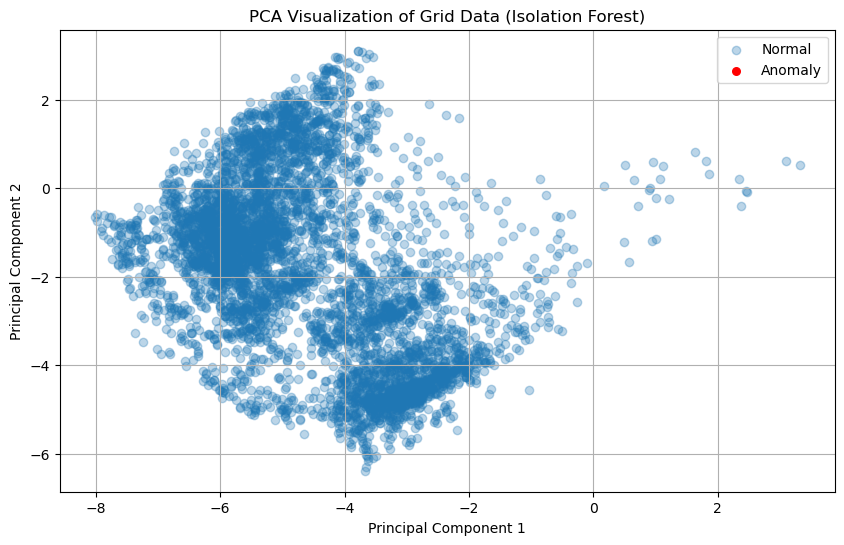

In [48]:
#PCA Scatter Plot to validate isolation forest
whole_pca = PCA(n_components=2)
whole_data_pca = whole_pca.fit_transform(X_scaled)
whole_pca_df = pd.DataFrame(whole_data_pca, columns=['PC1', 'PC2'])
whole_pca_df['anomaly'] = full_df['if_anomaly_flag'].values

plt.figure(figsize=(10, 6))

# Normal points
plt.scatter(
    whole_pca_df[whole_pca_df['anomaly'] == 1]['PC1'],
    whole_pca_df[whole_pca_df['anomaly'] == 1]['PC2'],
    label='Normal',
    alpha=0.3
)

# Anomaly points
plt.scatter(
    whole_pca_df[whole_pca_df['anomaly'] == -1]['PC1'],
    whole_pca_df[whole_pca_df['anomaly'] == -1]['PC2'],
    label='Anomaly',
    color='red',
    alpha=1,
    s=30
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Grid Data (Isolation Forest)')
plt.legend()
plt.grid()

plt.show()

In [49]:
#PCA Scatter Plot to check if anomalies df can be clustered
pca = PCA(n_components=2)
anomalies_pca = pca.fit_transform(anomalies_df)
pca_df = pd.DataFrame(anomalies_pca, columns=['PC1', 'PC2'])

In [50]:
pca_df['anomaly'] = anomalies_df['if_anomaly_flag'].values

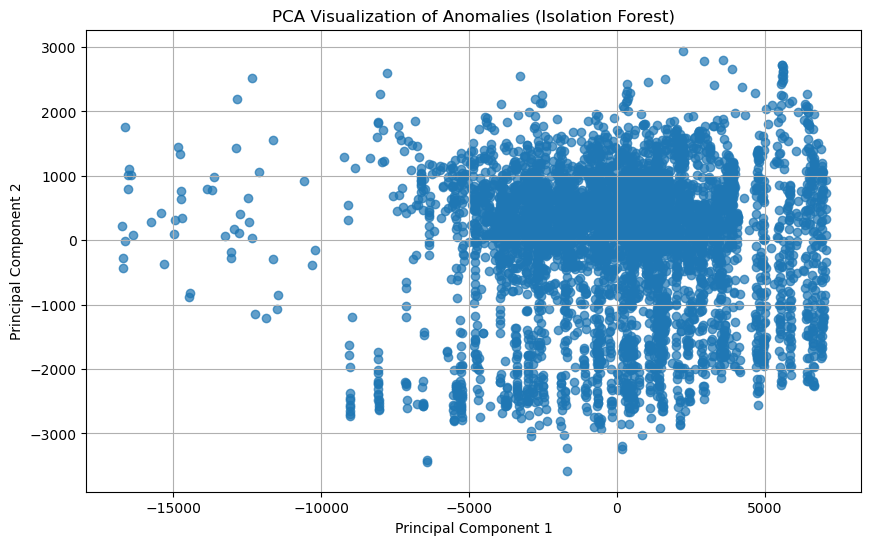

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Anomalies (Isolation Forest)')
plt.grid()

plt.show()

PCA visualization of anomalies showed a dominant dense region along with smaller dispersed groups, indicating the presence of multiple anomaly patterns. Based on this observation, clustering was applied to categorize different types of grid stress events.

In [54]:
#Applying K-Means
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_cols = anomalies_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col not in ['if_anomaly_flag', 'if_anomaly_score', 'cluster']]
scaler = StandardScaler()
X_anom_scaled = scaler.fit_transform(anomalies_df[feature_cols])
kmeans = KMeans(n_clusters=3, random_state=42)
anomalies_df['cluster'] = kmeans.fit_predict(X_anom_scaled)
anomalies_df['cluster'].value_counts()

cluster_summary = anomalies_df.groupby('cluster')[feature_cols].mean()
cluster_summary_df = pd.DataFrame(cluster_summary)

In [55]:
cluster_summary_df

,net_load_ramp,demand_ramp,solar_ramp,wind_ramp,demand_volatility_6h,solar_penetration,heat_index_c,heatwave_index,humidity_pct,hour_sin,...,month_sin,month_cos,demand_rolling_std_7d,demand_rolling_max_24h,is_weekend,is_peak_hour,low_ren_high_dem,is_extreme_temp,is_extreme_demand,dhi_wm2
cluster,,,,,,,,,,,,,,,,,,,,,
0,515.209125,366.966465,-219.901698,280.298071,3140.556721,0.253370,31.402677,67.721503,27.398497,-0.667800,...,-0.694003,-0.535882,5447.049856,40712.425590,0.246978,0.159758,0.044905,0.994387,0.905440,129.724180
1,685.944757,-153.398295,-890.570332,224.003922,2344.994138,0.085723,26.690949,61.044501,39.361826,-0.942594,...,-0.651467,-0.522214,5375.254977,39677.015345,0.337596,0.937084,0.726854,0.083376,0.882353,22.739983
2,-42.200000,311.354209,370.328956,-94.203367,1217.332380,0.318705,30.842264,74.275758,28.482225,0.464174,...,-0.681220,-0.493470,5717.669123,40230.310774,0.726263,0.000000,0.125253,0.921212,0.003030,181.435758


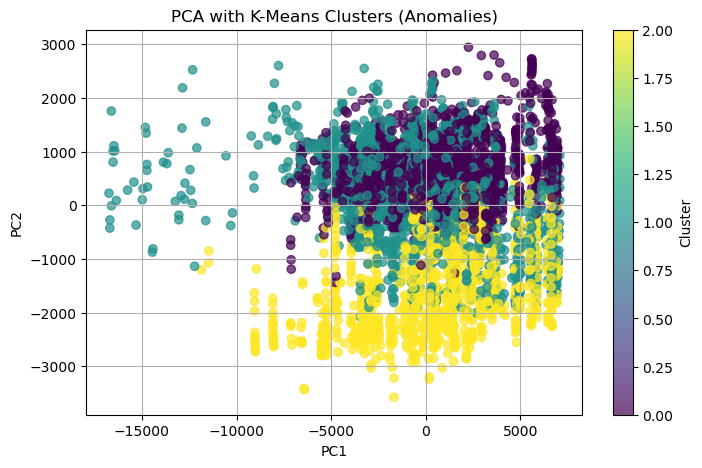

In [56]:
plt.figure(figsize=(8,5))

plt.scatter(pca_df['PC1'], pca_df['PC2'], 
            c=anomalies_df['cluster'], cmap='viridis', alpha=0.7)

plt.title("PCA with K-Means Clusters (Anomalies)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.grid()

plt.show()